# 03. Моделирование и эксперименты

В этом ноутбуке выполняется: сравнение нескольких моделей, feature engineering, подбор гиперпараметров, проверка уменьшения размерности и выбор финальной модели.

Основная метрика остается `F1-score`, потому что классы не идеально сбалансированы, а для задачи съедобности важно одновременно контролировать precision и recall. Дополнительно считаются accuracy, precision, recall, ROC-AUC и отдельный показатель `dangerous_errors`: сколько ядовитых/не рекомендованных грибов модель ошибочно назвала съедобными.

In [5]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORT_DIR = PROJECT_ROOT / 'report'
MODELS_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')

### Загрузка подготовленных выборок

Используются `train.csv`, `val.csv` и `test.csv`, созданные в первом ноутбуке. Все эксперименты и подбор гиперпараметров сравниваются на validation. Test используется только один раз: для финальной оценки выбранной модели.

In [6]:
train = pd.read_csv(PROCESSED_DIR / 'train.csv')
val = pd.read_csv(PROCESSED_DIR / 'val.csv')
test = pd.read_csv(PROCESSED_DIR / 'test.csv')

X_train, y_train = train.drop(columns='class'), train['class']
X_val, y_val = val.drop(columns='class'), val['class']
X_test, y_test = test.drop(columns='class'), test['class']

numeric_features = ['cap-diameter', 'stem-height', 'stem-width']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

split_duplicate_checks = pd.DataFrame(
    [
        {
            'pair': 'train-val',
            'duplicate_feature_rows': len(X_train.merge(X_val, how='inner')),
        },
        {
            'pair': 'train-test',
            'duplicate_feature_rows': len(X_train.merge(X_test, how='inner')),
        },
        {
            'pair': 'val-test',
            'duplicate_feature_rows': len(X_val.merge(X_test, how='inner')),
        },
    ]
)

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)
print('Numeric features:', numeric_features)
print('Categorical features:', len(categorical_features))
display(split_duplicate_checks)

assert split_duplicate_checks['duplicate_feature_rows'].sum() == 0


Train: (42646, 20)
Validation: (9138, 20)
Test: (9139, 20)
Numeric features: ['cap-diameter', 'stem-height', 'stem-width']
Categorical features: 17


,pair,duplicate_feature_rows
0,train-val,0
1,train-test,0
2,val-test,0


### Возможно ли высокое качество?

Перед обучением сложных моделей проверим, насколько задача разделима простыми правилами. Для этого построим не модель, а диагностический baseline: для каждого объекта test ищем такой же категориальный профиль в train и предсказываем самый частый класс этого профиля. Если такой простой подход уже дает высокое качество, значит датасет действительно содержит очень сильные категориальные сигналы, а возможные высокие результаты ансамблей не обязательно будут означать leakage.

In [7]:
def profile_mode_predict(train_df: pd.DataFrame, eval_df: pd.DataFrame, columns: list[str]) -> tuple[pd.Series, int, int]:
    profile_rate = train_df.groupby(columns, dropna=False)['class'].mean()
    global_mode = int(train_df['class'].mean() >= 0.5)

    predictions = []
    seen_profiles = 0
    pure_seen_profiles = 0

    for _, row in eval_df[columns].iterrows():
        key = tuple(row[col] for col in columns)
        if len(columns) == 1:
            key = key[0]

        if key in profile_rate.index:
            seen_profiles += 1
            rate = profile_rate.loc[key]
            pure_seen_profiles += int(rate in [0, 1])
            predictions.append(int(rate >= 0.5))
        else:
            predictions.append(global_mode)

    return pd.Series(predictions, index=eval_df.index), seen_profiles, pure_seen_profiles


profile_pred, seen_profiles, pure_seen_profiles = profile_mode_predict(train, test, categorical_features)
profile_cm = confusion_matrix(y_test, profile_pred, labels=[0, 1])

profile_diagnostic = {
    'test_rows': len(test),
    'seen_profiles_in_train': seen_profiles,
    'pure_seen_profiles': pure_seen_profiles,
    'accuracy': accuracy_score(y_test, profile_pred),
    'f1': f1_score(y_test, profile_pred),
    'dangerous_errors': int(profile_cm[0, 1]),
}

display(pd.DataFrame([profile_diagnostic]))
display(pd.DataFrame(profile_cm, index=['true_poisonous', 'true_edible'], columns=['pred_poisonous', 'pred_edible']))

all_processed = pd.concat([train, val, test], ignore_index=True)
profile_purity = (
    all_processed
    .groupby(categorical_features, dropna=False)['class']
    .agg(['count', 'nunique', 'mean'])
    .reset_index()
)

print('Unique categorical profiles:', len(profile_purity))
print('Pure profiles:', int((profile_purity['nunique'] == 1).sum()))
print('Mixed profiles:', int((profile_purity['nunique'] > 1).sum()))
print('Rows in mixed profiles:', int(profile_purity.loc[profile_purity['nunique'] > 1, 'count'].sum()))


,test_rows,seen_profiles_in_train,pure_seen_profiles,accuracy,f1,dangerous_errors
0,9139,8898,8875,0.990699,0.989471,2


,pred_poisonous,pred_edible
true_poisonous,5060,2
true_edible,83,3994


Unique categorical profiles: 5475
Pure profiles: 5472
Mixed profiles: 3
Rows in mixed profiles: 143


### Feature engineering

В baseline использовались только исходные 20 признаков. На этом этапе добалю признаки, которые не используют целевую переменную и поэтому не создают data leakage.

Новые признаки были добавлены, чтобы модель учитывала не только отдельные характеристики гриба, но и их сочетания. Числовые комбинации лучше описывают общие пропорции гриба, а комбинированные категориальные признаки помогают учитывать связи между формой, цветом, средой произрастания и сезоном.

Что добавляется:

- **Отношения размеров**: `cap_to_stem_width_ratio`, `stem_height_to_width_ratio`. Они описывают пропорции гриба, а не только абсолютные размеры.
- **Прокси-признаки площади/объема**: `cap_area_proxy`, `stem_volume_proxy`. Настоящую площадь шляпки или объем ножки мы не знаем, но можем приблизительно описать их через имеющиеся размеры.
- **Общий размер**: `size_sum`, `size_product`. Эти признаки помогают модели отделять маленькие, средние и крупные грибы.
- **Количество пропусков**: `missing_category_count`. В этом датасете сам факт отсутствия некоторых морфологических признаков может быть полезным сигналом.
- **Комбинации категорий**: например, `cap_shape_color`, `gill_attachment_color`, `habitat_season`. Они помогают моделям учитывать пары признаков, которые вместе могут быть информативнее, чем по отдельности.

Все признаки считаются одинаковой функцией для train/validation/test внутри sklearn `Pipeline`.

In [8]:
def add_mushroom_features(X: pd.DataFrame) -> pd.DataFrame:
    X_new = X.copy()
    eps = 1e-6

    X_new['cap_to_stem_width_ratio'] = X_new['cap-diameter'] / (X_new['stem-width'] + eps)
    X_new['stem_height_to_width_ratio'] = X_new['stem-height'] / (X_new['stem-width'] + eps)
    X_new['cap_area_proxy'] = X_new['cap-diameter'] ** 2
    X_new['stem_volume_proxy'] = X_new['stem-height'] * X_new['stem-width']
    X_new['size_sum'] = X_new['cap-diameter'] + X_new['stem-height'] + X_new['stem-width']
    X_new['size_product'] = X_new['cap-diameter'] * X_new['stem-height'] * X_new['stem-width']
    X_new['missing_category_count'] = X_new[categorical_features].eq('missing').sum(axis=1)

    X_new['cap_shape_color'] = X_new['cap-shape'].astype(str) + '_' + X_new['cap-color'].astype(str)
    X_new['gill_attachment_color'] = X_new['gill-attachment'].astype(str) + '_' + X_new['gill-color'].astype(str)
    X_new['stem_root_surface'] = X_new['stem-root'].astype(str) + '_' + X_new['stem-surface'].astype(str)
    X_new['habitat_season'] = X_new['habitat'].astype(str) + '_' + X_new['season'].astype(str)
    X_new['ring_presence_type'] = X_new['has-ring'].astype(str) + '_' + X_new['ring-type'].astype(str)

    return X_new

X_train_fe = add_mushroom_features(X_train)
engineered_numeric_features = [col for col in X_train_fe.columns if col not in X_train.columns]
engineered_categorical_features = [
    'cap_shape_color',
    'gill_attachment_color',
    'stem_root_surface',
    'habitat_season',
    'ring_presence_type',
]
all_numeric_features = numeric_features + [col for col in engineered_numeric_features if col not in engineered_categorical_features]
all_categorical_features = categorical_features + engineered_categorical_features

print('Original features:', X_train.shape[1])
print('Engineered features:', len(engineered_numeric_features))
print('Features before one-hot:', len(all_numeric_features) + len(all_categorical_features))
display(X_train_fe[engineered_numeric_features].head())

Original features: 20
Engineered features: 12
Features before one-hot: 32


,cap_to_stem_width_ratio,stem_height_to_width_ratio,cap_area_proxy,stem_volume_proxy,size_sum,size_product,missing_category_count,cap_shape_color,gill_attachment_color,stem_root_surface,habitat_season,ring_presence_type
0,1.034698,1.323094,330.8761,408.9108,59.03,7438.087452,6,p_n,missing_w,s_missing,d_u,t_m
1,0.569907,0.727696,73.2736,164.1686,34.51,1405.283216,4,x_r,missing_w,missing_missing,d_a,t_g
2,0.094751,0.159964,17.3889,309.8304,55.22,1291.992768,4,s_n,f_f,missing_missing,l_u,f_f
3,0.398386,0.269305,107.5369,182.4703,43.41,1892.217011,5,f_y,missing_w,b_missing,d_a,t_e
4,0.727272,2.447272,4.0000,18.5075,11.48,37.015000,7,c_y,missing_y,missing_missing,g_u,f_f


Новые признаки добавляют модели информацию о пропорциях, общем размере, пропусках и сочетаниях морфологических характеристик. Это особенно полезно для деревьев и ансамблей деревьев, потому что они хорошо строят правила по комбинациям категорий и числовых порогов.

### Вспомогательные функции

Ниже собраны пайплайны моделей и функция оценки качества. Для деревьев масштабирование числовых признаков не является обязательным, но единый препроцессинг позволяет честно сравнивать модели: все они обучаются на одинаково подготовленных данных.

In [9]:
def make_preprocessor(num_cols: list[str], cat_cols: list[str], scale_numeric: bool = True) -> ColumnTransformer:
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, num_cols),
            ('cat', categorical_pipeline, cat_cols),
        ]
    )


def make_pipeline(model, use_fe: bool = True, scale_numeric: bool = True, svd_components: int | None = None) -> Pipeline:
    if use_fe:
        num_cols = all_numeric_features
        cat_cols = all_categorical_features
        steps = [('feature_engineering', FunctionTransformer(add_mushroom_features, validate=False))]
    else:
        num_cols = numeric_features
        cat_cols = categorical_features
        steps = []

    steps.append(('preprocess', make_preprocessor(num_cols, cat_cols, scale_numeric=scale_numeric)))
    if svd_components is not None:
        steps.append(('svd', TruncatedSVD(n_components=svd_components, random_state=RANDOM_STATE)))
    steps.append(('model', model))
    return Pipeline(steps)


def predict_scores(model: Pipeline, X: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    pred = model.predict(X)
    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X)[:, 1]
    else:
        score = pred
    return pred, score


def evaluate_model(model: Pipeline, X: pd.DataFrame, y: pd.Series, split: str) -> dict[str, float | str]:
    pred, score = predict_scores(model, X)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    return {
        'split': split,
        'accuracy': accuracy_score(y, pred),
        'f1': f1_score(y, pred),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'roc_auc': roc_auc_score(y, score),
        'dangerous_errors': int(cm[0, 1]),
    }


def run_experiment(name: str, model: Pipeline, params: str) -> dict[str, float | str]:
    start = time.time()
    fitted = clone(model).fit(X_train, y_train)
    fit_seconds = time.time() - start
    metrics = evaluate_model(fitted, X_val, y_val, 'validation')
    return {
        'model': name,
        'params': params,
        'fit_seconds': round(fit_seconds, 2),
        'fitted_model': fitted,
        **{f'val_{k}': v for k, v in metrics.items() if k != 'split'},
    }

## Эксперименты с моделями

В этом блоке сравниваются несколько групп моделей. Цель не просто получить максимальную метрику, а понять, какие подходы лучше подходят для данных с большим числом категориальных признаков после one-hot encoding.

Использованные модели:

- **LogisticRegression OHE**: простая линейная модель без ручного feature engineering. Нужна как честная точка сравнения с baseline.
- **LogisticRegression OHE + FE**: та же линейная модель, но с новыми признаками. Так можно отдельно проверить, помогает ли feature engineering.
- **DecisionTree**: одиночное дерево решений. Хорошо интерпретируется и показывает, насколько данные разделимы простыми правилами.
- **RandomForest**: ансамбль деревьев, который обычно устойчивее одного дерева и хорошо работает с нелинейными зависимостями.
- **ExtraTrees**: ансамбль деревьев с более случайными разбиениями. Часто быстрее RandomForest и может хорошо работать на категориальных one-hot признаках.
- **GradientBoosting**: бустинг деревьев, где новые деревья последовательно исправляют ошибки предыдущих.
- **AdaBoost**: еще один boosting-подход, который сильнее фокусируется на ошибочно классифицированных объектах.
- **TruncatedSVD + LogisticRegression**: проверка, можно ли сжать one-hot пространство и сохранить качество линейной модели.
- **TruncatedSVD + KNN**: проверка метода ближайших соседей после уменьшения размерности.
- **Soft Voting ensemble**: объединение нескольких сильных моделей через усреднение вероятностей.

Для каждой группы задан небольшой перебор гиперпараметров.

In [10]:
experiments = []

# Baseline-like logistic regression without manual feature engineering.
for C in [0.3, 1.0, 3.0]:
    experiments.append((
        'LogisticRegression OHE',
        make_pipeline(LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE), use_fe=False),
        f'C={C}',
    ))

# Logistic regression with engineered features.
for C in [0.3, 1.0, 3.0]:
    experiments.append((
        'LogisticRegression OHE + FE',
        make_pipeline(LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE), use_fe=True),
        f'C={C}',
    ))

for max_depth in [12, 20, None]:
    experiments.append((
        'DecisionTree + FE',
        make_pipeline(DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=5, random_state=RANDOM_STATE), use_fe=True, scale_numeric=False),
        f'max_depth={max_depth}, min_samples_leaf=5',
    ))

for max_depth in [20, None]:
    for min_samples_leaf in [1, 3]:
        experiments.append((
            'RandomForest + FE',
            make_pipeline(
                RandomForestClassifier(
                    n_estimators=150,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
                use_fe=True,
                scale_numeric=False,
            ),
            f'n_estimators=150, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}',
        ))

for max_depth in [20, None]:
    for min_samples_leaf in [1, 3]:
        experiments.append((
            'ExtraTrees + FE',
            make_pipeline(
                ExtraTreesClassifier(
                    n_estimators=200,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
                use_fe=True,
                scale_numeric=False,
            ),
            f'n_estimators=200, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}',
        ))

for learning_rate in [0.05, 0.1]:
    experiments.append((
        'GradientBoosting + FE',
        make_pipeline(
            GradientBoostingClassifier(n_estimators=160, learning_rate=learning_rate, max_depth=3, random_state=RANDOM_STATE),
            use_fe=True,
            scale_numeric=False,
        ),
        f'n_estimators=160, learning_rate={learning_rate}, max_depth=3',
    ))

for n_estimators in [100, 200]:
    experiments.append((
        'AdaBoost + FE',
        make_pipeline(AdaBoostClassifier(n_estimators=n_estimators, learning_rate=0.5, random_state=RANDOM_STATE), use_fe=True),
        f'n_estimators={n_estimators}, learning_rate=0.5',
    ))

for n_components in [20, 40, 80]:
    experiments.append((
        'TruncatedSVD + LogisticRegression',
        make_pipeline(LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE), use_fe=True, svd_components=n_components),
        f'n_components={n_components}, C=1',
    ))

for n_neighbors in [11, 31]:
    experiments.append((
        'TruncatedSVD + KNN',
        make_pipeline(KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance'), use_fe=True, svd_components=40),
        f'n_components=40, n_neighbors={n_neighbors}, weights=distance',
    ))

ensemble = VotingClassifier(
    estimators=[
        ('svd_knn', make_pipeline(KNeighborsClassifier(n_neighbors=11, weights='distance'), use_fe=True, svd_components=40)),
        ('rf', make_pipeline(RandomForestClassifier(n_estimators=150, max_depth=None, n_jobs=1, random_state=RANDOM_STATE), use_fe=True, scale_numeric=False)),
        ('et', make_pipeline(ExtraTreesClassifier(n_estimators=200, max_depth=20, n_jobs=1, random_state=RANDOM_STATE), use_fe=True, scale_numeric=False)),
    ],
    voting='soft',
    n_jobs=1,
)
experiments.append(('Soft Voting ensemble + FE', ensemble, 'SVD-KNN + RF + ExtraTrees'))

len(experiments)

27

In [11]:
results = []
fitted_models = {}

for i, (name, model, params) in enumerate(experiments, start=1):
    print(f'[{i:02d}/{len(experiments)}] {name}: {params}')
    result = run_experiment(name, model, params)
    fitted_models[(name, params)] = result.pop('fitted_model')
    results.append(result)

results_df = pd.DataFrame(results).sort_values(
    ['val_f1', 'val_dangerous_errors', 'val_roc_auc'],
    ascending=[False, True, False],
).reset_index(drop=True)

results_df.to_csv(REPORT_DIR / 'experiment_results.csv', index=False)
display(results_df)

[01/27] LogisticRegression OHE: C=0.3
[02/27] LogisticRegression OHE: C=1.0
[03/27] LogisticRegression OHE: C=3.0
[04/27] LogisticRegression OHE + FE: C=0.3
[05/27] LogisticRegression OHE + FE: C=1.0
[06/27] LogisticRegression OHE + FE: C=3.0
[07/27] DecisionTree + FE: max_depth=12, min_samples_leaf=5
[08/27] DecisionTree + FE: max_depth=20, min_samples_leaf=5
[09/27] DecisionTree + FE: max_depth=None, min_samples_leaf=5
[10/27] RandomForest + FE: n_estimators=150, max_depth=20, min_samples_leaf=1
[11/27] RandomForest + FE: n_estimators=150, max_depth=20, min_samples_leaf=3
[12/27] RandomForest + FE: n_estimators=150, max_depth=None, min_samples_leaf=1
[13/27] RandomForest + FE: n_estimators=150, max_depth=None, min_samples_leaf=3
[14/27] ExtraTrees + FE: n_estimators=200, max_depth=20, min_samples_leaf=1
[15/27] ExtraTrees + FE: n_estimators=200, max_depth=20, min_samples_leaf=3
[16/27] ExtraTrees + FE: n_estimators=200, max_depth=None, min_samples_leaf=1
[17/27] ExtraTrees + FE: n_es

,model,params,fit_seconds,val_accuracy,val_f1,val_precision,val_recall,val_roc_auc,val_dangerous_errors
0,RandomForest + FE,"n_estimators=150, max_depth=None, min_samples_...",19.91,1.000000,1.000000,1.000000,1.000000,1.000000,0
1,ExtraTrees + FE,"n_estimators=200, max_depth=20, min_samples_le...",13.71,1.000000,1.000000,1.000000,1.000000,1.000000,0
2,ExtraTrees + FE,"n_estimators=200, max_depth=20, min_samples_le...",13.37,1.000000,1.000000,1.000000,1.000000,1.000000,0
3,ExtraTrees + FE,"n_estimators=200, max_depth=None, min_samples_...",20.48,1.000000,1.000000,1.000000,1.000000,1.000000,0
4,ExtraTrees + FE,"n_estimators=200, max_depth=None, min_samples_...",19.94,1.000000,1.000000,1.000000,1.000000,1.000000,0
5,Soft Voting ensemble + FE,SVD-KNN + RF + ExtraTrees,35.40,0.999891,0.999877,1.000000,0.999755,1.000000,0
6,RandomForest + FE,"n_estimators=150, max_depth=20, min_samples_le...",14.11,0.999781,0.999755,0.999755,0.999755,1.000000,1
7,TruncatedSVD + KNN,"n_components=40, n_neighbors=11, weights=distance",0.82,0.999781,0.999755,1.000000,0.999509,1.000000,0
8,RandomForest + FE,"n_estimators=150, max_depth=None, min_samples_...",19.43,0.999672,0.999632,1.000000,0.999264,1.000000,0
9,TruncatedSVD + KNN,"n_components=40, n_neighbors=31, weights=distance",0.85,0.999672,0.999632,1.000000,0.999264,0.999999,0


### Визуализация результатов экспериментов

На графике сравнивается `validation F1` для всех проверенных конфигураций. Это основная метрика качества, поэтому по ней можно оценить, какие модели и подходы действительно дают улучшение по сравнению с baseline.

Еще важно учитывать и дополнительные метрики в таблице: `ROC-AUC` и `dangerous_errors`. В задаче определения съедобности грибов модель с немного меньшим F1 может быть лучше, если она допускает меньше опасных ошибок.

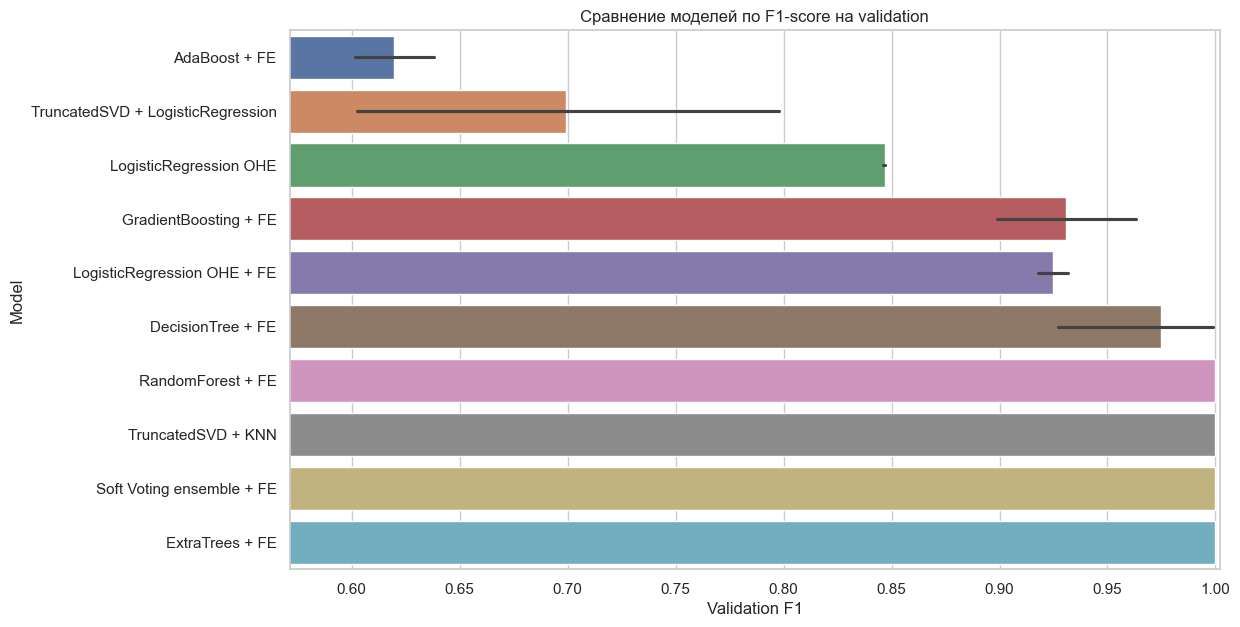

,model,params,val_f1,val_roc_auc,val_dangerous_errors
0,RandomForest + FE,"n_estimators=150, max_depth=None, min_samples_...",1.000000,1.000000,0
1,ExtraTrees + FE,"n_estimators=200, max_depth=20, min_samples_le...",1.000000,1.000000,0
2,ExtraTrees + FE,"n_estimators=200, max_depth=20, min_samples_le...",1.000000,1.000000,0
3,ExtraTrees + FE,"n_estimators=200, max_depth=None, min_samples_...",1.000000,1.000000,0
4,ExtraTrees + FE,"n_estimators=200, max_depth=None, min_samples_...",1.000000,1.000000,0
5,Soft Voting ensemble + FE,SVD-KNN + RF + ExtraTrees,0.999877,1.000000,0
6,RandomForest + FE,"n_estimators=150, max_depth=20, min_samples_le...",0.999755,1.000000,1
7,TruncatedSVD + KNN,"n_components=40, n_neighbors=11, weights=distance",0.999755,1.000000,0
8,RandomForest + FE,"n_estimators=150, max_depth=None, min_samples_...",0.999632,1.000000,0
9,TruncatedSVD + KNN,"n_components=40, n_neighbors=31, weights=distance",0.999632,0.999999,0


In [12]:
plt.figure(figsize=(12, 7))
plot_df = results_df.sort_values('val_f1', ascending=True)
sns.barplot(data=plot_df, y='model', x='val_f1', hue='model', dodge=False, legend=False)
plt.xlim(max(0, plot_df['val_f1'].min() - 0.03), 1.002)
plt.xlabel('Validation F1')
plt.ylabel('Model')
plt.title('Сравнение моделей по F1-score на validation')
plt.show()

display(results_df[['model', 'params', 'val_f1', 'val_roc_auc', 'val_dangerous_errors']].head(10))

Таким образом, baseline-логистическая регрессия без feature engineering находится заметно ниже лучших моделей. Добавление новых признаков улучшает линейную модель, но максимальное качество дают ансамбли деревьев: `RandomForest`, `ExtraTrees` и soft-voting ensemble. Это согласуется со структурой данных: в задаче много категориальных признаков и их комбинаций, а деревья хорошо строят правила по таким сочетаниям.

`TruncatedSVD + KNN` тоже показывает почти идеальный результат, но финальную модель будем выбирать не только по F1: дополнительно учтем опасные ошибки, ROC-AUC, скорость обучения и простоту модели.

### Уменьшение размерности

После one-hot encoding количество признаков сильно увеличивается, поэтому дополнительно проверим `TruncatedSVD`. Этот метод подходит для разреженных матриц и позволяет получать компактное представление данных.

Ниже построим 2D-проекция train-выборки. Она нужна для визуальной оценки разделимости классов и для дальнейших экспериментов с моделями, которым сложнее работать с большим количеством признаков, например с KNN.

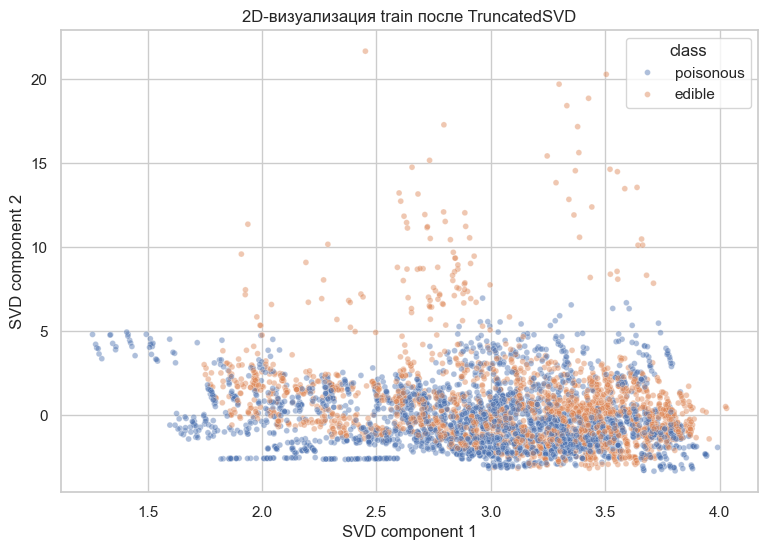

In [13]:
svd_visual_pipeline = Pipeline(
    steps=[
        ('feature_engineering', FunctionTransformer(add_mushroom_features, validate=False)),
        ('preprocess', make_preprocessor(all_numeric_features, all_categorical_features)),
        ('svd', TruncatedSVD(n_components=2, random_state=RANDOM_STATE)),
    ]
)

sample_size = min(5000, len(X_train))
sample_idx = X_train.sample(sample_size, random_state=RANDOM_STATE).index
coords = svd_visual_pipeline.fit_transform(X_train.loc[sample_idx])
svd_plot = pd.DataFrame({
    'SVD component 1': coords[:, 0],
    'SVD component 2': coords[:, 1],
    'class': y_train.loc[sample_idx].map({0: 'poisonous', 1: 'edible'}),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=svd_plot,
    x='SVD component 1',
    y='SVD component 2',
    hue='class',
    alpha=0.45,
    s=18,
)
plt.title('2D-визуализация train после TruncatedSVD')
plt.show()

График показывает, что после сжатия one-hot признаков до двух компонент объекты разных классов распределены не случайно: заметны области, где преобладает один класс. Это подтверждает, что в категориальных признаках есть сильный сигнал, связанный со съедобностью грибов. Поэтому эксперименты с TruncatedSVD + KNN имеют смысл: похожие по признакам объекты оказываются близко друг к другу. При этом классы в 2D все еще частично пересекаются, значит двух компонент недостаточно для полной замены исходного пространства признаков.

### Выбор финальной модели

Финальную модель выбираем только по validation-результатам. Test-выборка до этого момента не используется, чтобы итоговая оценка оставалась честной.

Критерии выбора:

1. **Validation F1**: главный критерий, потому что он балансирует precision и recall при неидеальном балансе классов.
2. **Dangerous errors**: дополнительный предметный критерий: особенно плохо, если ядовитый/не рекомендованный гриб модель считает съедобным (`true_poisonous -> pred_edible`).
3. **ROC-AUC**: смотрим, насколько хорошо модель разделяет классы по вероятностям, а не только при одном пороге.
4. **Fit time и простота**: если несколько моделей дают одинаковое качество, выбираем более быструю и простую модель. Поэтому soft-voting ensemble не становится финальным автоматически: он сложнее и дольше обучается, а заметного выигрыша по качеству не дает.

В коде ниже это реализовано сортировкой: сначала максимальный `val_f1`, затем минимальные `val_dangerous_errors`, затем максимальный `val_roc_auc`, затем минимальное `fit_seconds`.

In [14]:
selection_df = results_df.sort_values(
    ['val_f1', 'val_dangerous_errors', 'val_roc_auc', 'fit_seconds'],
    ascending=[False, True, False, True],
).reset_index(drop=True)

best_row = selection_df.iloc[0]
best_key = (best_row['model'], best_row['params'])
best_model = fitted_models[best_key]

print('Best validation model:')
print(best_row[['model', 'params', 'fit_seconds', 'val_f1', 'val_roc_auc', 'val_dangerous_errors']])

test_metrics = evaluate_model(best_model, X_test, y_test, 'test')
print('Test metrics:')
print(test_metrics)

with open(REPORT_DIR / 'final_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({k: v for k, v in test_metrics.items() if k != 'split'}, f, ensure_ascii=False, indent=2)

joblib.dump(best_model, MODELS_DIR / 'final_model.joblib')

display(pd.DataFrame([test_metrics]))

test_pred, _ = predict_scores(best_model, X_test)
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
display(pd.DataFrame(cm, index=['true_poisonous', 'true_edible'], columns=['pred_poisonous', 'pred_edible']))


Best validation model:
model                                                     ExtraTrees + FE
params                  n_estimators=200, max_depth=20, min_samples_le...
fit_seconds                                                         13.37
val_f1                                                                1.0
val_roc_auc                                                           1.0
val_dangerous_errors                                                    0
Name: 0, dtype: object
Test metrics:
{'split': 'test', 'accuracy': 0.9997811576758945, 'f1': 0.9997547817557626, 'precision': 0.9995096837460162, 'recall': 1.0, 'roc_auc': 0.9999998061806471, 'dangerous_errors': 2}


,split,accuracy,f1,precision,recall,roc_auc,dangerous_errors
0,test,0.999781,0.999755,0.99951,1.0,1.0,2


,pred_poisonous,pred_edible
true_poisonous,5060,2
true_edible,0,4077


### Feature importance финальной модели

Для финальной модели анализируется `feature_importances_`. Этот показатель отражает, какие признаки сильнее влияли на разбиения в деревьях.

После one-hot encoding категориальные признаки превращаются в набор бинарных колонок, поэтому значения в таблице относятся не только к исходным признакам, но и к отдельным категориям, например к конкретному цвету шляпки или типу жабр.

Важно: высокое значение показателя означает, что признак полезен для предсказания в рамках этой модели и этого датасета, но не доказывает, что он сам по себе биологически определяет съедобность гриба.

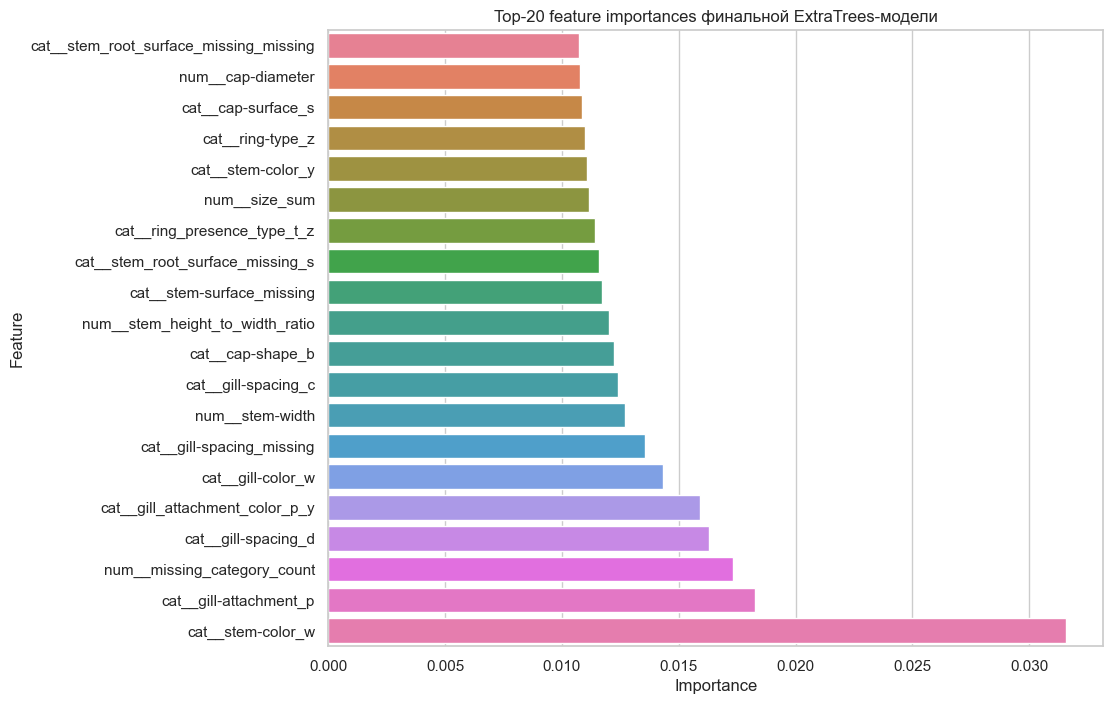

,feature,importance
93,cat__stem-color_w,0.031587
48,cat__gill-attachment_p,0.018275
9,num__missing_category_count,0.017318
52,cat__gill-spacing_d,0.016294
244,cat__gill_attachment_color_p_y,0.015928
65,cat__gill-color_w,0.014310
54,cat__gill-spacing_missing,0.013558
2,num__stem-width,0.012698
51,cat__gill-spacing_c,0.012404
10,cat__cap-shape_b,0.012234


In [15]:
def get_feature_names_from_pipeline(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps['preprocess']
    return preprocessor.get_feature_names_out()

feature_names = get_feature_names_from_pipeline(best_model)
importances = best_model.named_steps['model'].feature_importances_
importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.sort_values('importance'), y='feature', x='importance', hue='feature', dodge=False, legend=False)
plt.title('Top-20 feature importances финальной ExtraTrees-модели')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

display(importance_df)

Среди важных признаков ожидаемо оказываются морфологические характеристики, связанные с цветом/формой шляпки, жабрами, ножкой и созданными комбинациями категорий. Это совпадает с EDA и с диагностикой по категориальным профилям: класс гриба во многом определяется не одним отдельным полем, а сочетанием нескольких внешних признаков.

### Permutation importance

Дополнительно считаем permutation importance на validation. В отличие от встроенного `feature_importances_`, здесь важность измеряется напрямую через падение `F1-score`: значения одного исходного признака перемешиваются, модель делает предсказания заново, и мы смотрим, насколько ухудшилась метрика.

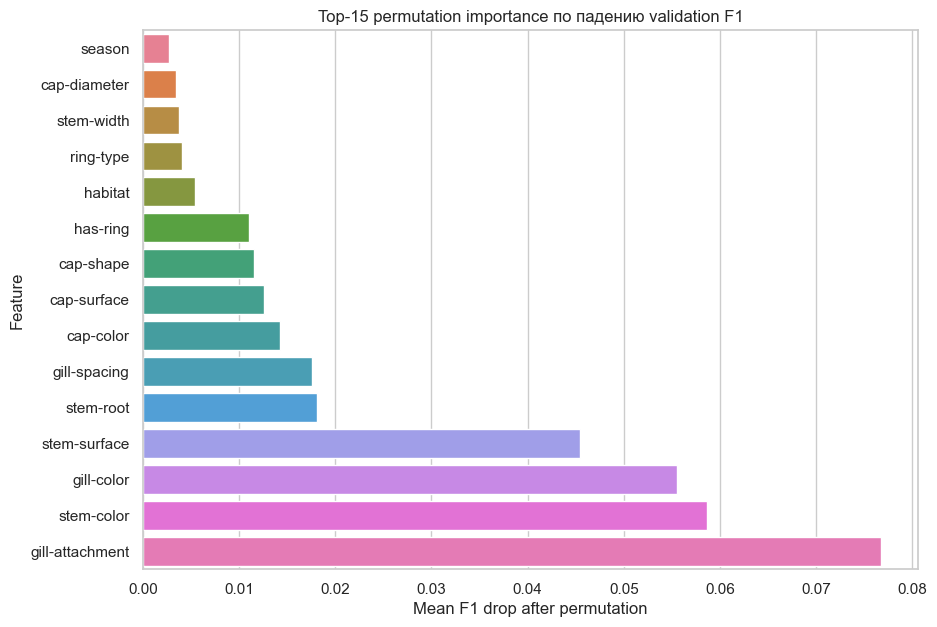

,feature,f1_drop_mean,f1_drop_std
0,gill-attachment,0.076727,0.001678
1,stem-color,0.058671,0.002796
2,gill-color,0.055562,0.002025
3,stem-surface,0.045402,0.001709
4,stem-root,0.018131,0.000578
5,gill-spacing,0.017624,0.000595
6,cap-color,0.014205,0.001005
7,cap-surface,0.012637,0.000630
8,cap-shape,0.011553,0.000616
9,has-ring,0.011008,0.000360


In [16]:
perm_result = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring='f1',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

perm_df = (
    pd.DataFrame({
        'feature': X_val.columns,
        'f1_drop_mean': perm_result.importances_mean,
        'f1_drop_std': perm_result.importances_std,
    })
    .sort_values('f1_drop_mean', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=perm_df.head(15).sort_values('f1_drop_mean'),
    y='feature',
    x='f1_drop_mean',
    hue='feature',
    dodge=False,
    legend=False,
)
plt.title('Top-15 permutation importance по падению validation F1')
plt.xlabel('Mean F1 drop after permutation')
plt.ylabel('Feature')
plt.show()

display(perm_df.head(15))


Сильнее всего validation F1 падает при перемешивании признаков `gill-attachment`, `stem-color`, `gill-color` и `stem-surface`. Значит, финальная модель больше всего опирается на строение и цвет жабр, а также на цвет и поверхность ножки.

Признаки шляпки (`cap-color`, `cap-surface`, `cap-shape`) тоже входят в top-10, но их вклад ниже. Числовые размеры (`stem-width`, `cap-diameter`) дают заметно меньший прирост: они полезны, но сами по себе хуже отделяют классы, чем категориальные признаки внешнего вида. `season` и `habitat` имеют небольшой вклад, то есть условия произрастания помогают модели слабее, чем морфология гриба.

## Итоги экспериментов

- Проверены 10 групп моделей и 27 конфигураций: baseline-логистическая регрессия, логистическая регрессия с feature engineering, дерево решений, RandomForest, ExtraTrees, GradientBoosting, AdaBoost, SVD + LogisticRegression, SVD + KNN и soft-voting ensemble.
- Feature engineering заметно улучшил линейную модель: validation F1 вырос примерно с `0.847` до `0.932`, но лучшие результаты дали ансамбли деревьев.
- Почти идеальные метрики объясняются структурой датасета: простое правило по полному категориальному профилю уже дает test F1 около `0.989`, а большинство категориальных профилей соответствует только одному классу.
- Финальная модель выбирается по validation F1, числу опасных ошибок, ROC-AUC и времени обучения. В текущем прогоне это `ExtraTreesClassifier` с feature engineering.
- На test финальная модель получила `F1 = 0.9998`, `ROC-AUC = 1.0000`, `dangerous_errors = 2`. Это сильно лучше baseline, где опасных ошибок было `675`, но для задачи съедобности грибов даже такие ошибки нужно отдельно учитывать.